## Task 1: Simple GRU Cell from Scratch

In [23]:
import numpy as np 

x_t = np.array([0.5, 0.8])
h_prev = np.array([0.2, 0.4])


W_z = np.array([[0.4, 0.3], [0.2, 0.5]])
U_z = np.array([[0.3, 0.2], [0.4, 0.1]])
b_z = np.array([0.1, 0.1])

W_r = np.array([[0.5, 0.2], [0.3, 0.4]])
U_r = np.array([[0.2, 0.3], [0.1, 0.5]])
b_r = np.array([0.1, 0.1])

W_h = np.array([[0.4, 0.3], [0.2, 0.6]])
U_h = np.array([[0.3, 0.2], [0.4, 0.1]])
b_h = np.array([0.1, 0.1])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


z_t = sigmoid(np.dot(W_z, x_t) + np.dot(U_z, h_prev) + b_z)
r_t = sigmoid(np.dot(W_r, x_t) + np.dot(U_r, h_prev) + b_r)

h_candidate = np.tanh(np.dot(W_h, x_t) + np.dot(U_h, r_t * h_prev) + b_h)

h_t = (1 - z_t) * h_prev + z_t * h_candidate

print("Update Gate:", z_t)
print("Reset Gate:", r_t)
print("Candidate Hiddent State:", h_candidate)
print("Next Hiddent State:", h_t)

Update Gate: [0.6637387  0.67260702]
Reset Gate: [0.66150316 0.68783133]
Candidate Hiddent State: [0.56129148 0.64133223]
Next Hiddent State: [0.43980313 0.56232175]


## Task 2: LSTM vs GRU Comparison

In [26]:
import pandas as pd

comparison = {
    "Number of Gates": [
        "LSTM has 3 gates: input, forget and output",
        "GRU has 2 gates: update and reset",
        "GRU combines input and forget functions into the update gate"
    ],
    "Parameters": [
        "LSTM has more trainable parameters",
        "GRU has fewer trainable parameters",
        "GRU is generally faster to train"
    ],
    "Information Flow": [
        "LSTM uses separate cell state and hidden state",
        "GRU uses a single hidden state",
        "GRU has a simpler information flow with fewer operations"
    ]
}

comparison_table = pd.DataFrame(comparison, index=["Difference 1", "Difference 2", "Difference 3"])

print(comparison_table)

                                                Number of Gates  \
Difference 1         LSTM has 3 gates: input, forget and output   
Difference 2                  GRU has 2 gates: update and reset   
Difference 3  GRU combines input and forget functions into t...   

                                      Parameters  \
Difference 1  LSTM has more trainable parameters   
Difference 2  GRU has fewer trainable parameters   
Difference 3    GRU is generally faster to train   

                                               Information Flow  
Difference 1     LSTM uses separate cell state and hidden state  
Difference 2                     GRU uses a single hidden state  
Difference 3  GRU has a simpler information flow with fewer ...  


## TAsk 3: Visualize GRU Update and Reset Gates

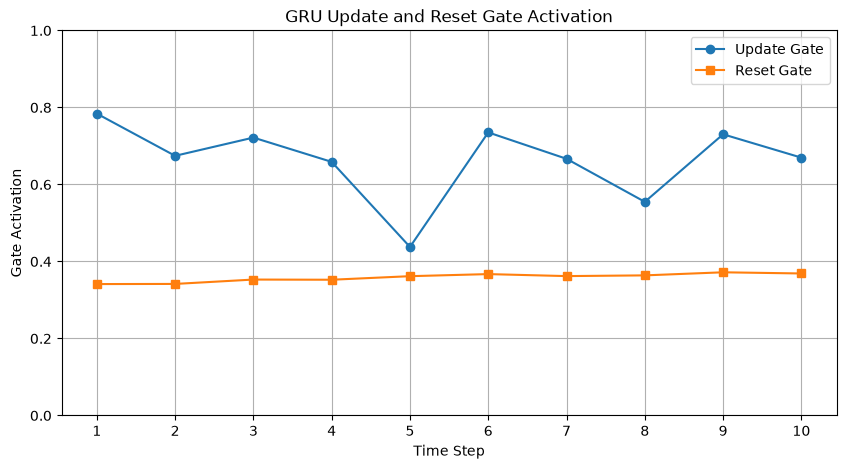

In [31]:
import numpy as np 
import matplotlib.pyplot as plt

ratings = np.array([3, 4, 5, 4, 2, 5, 4, 3, 5, 4], dtype=float)

hidden_size = 4
np.random.seed(42)

W_z = np.random.randn(hidden_size, 1)
U_z = np.random.randn(hidden_size, hidden_size)
b_z = np.random.randn(hidden_size)

W_r = np.random.randn(hidden_size, 1)
U_r = np.random.randn(hidden_size, hidden_size)
b_r = np.random.randn(hidden_size)

h = np.zeros(hidden_size)

update_values = []
reset_values = []

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

for x in ratings:
    x_t = np.array([x])
    z_t = sigmoid(W_z @ x_t + U_z @ h + b_z)
    r_t = sigmoid(W_r @ x_t + U_r @ h + b_r)

    h_candidate = np.tanh(W_z @ x_t + U_z @ (r_t * h) + b_z)
    h = (1 - z_t) * h + z_t * h_candidate

    update_values.append(np.mean(z_t))
    reset_values.append(np.mean(r_t))


time_steps = np.arange(1, len(ratings) + 1)

plt.figure(figsize=(10,5))
plt.plot(time_steps, update_values, marker="o", label="Update Gate")
plt.plot(time_steps, reset_values, marker="s", label="Reset Gate")
plt.xlabel("Time Step")
plt.ylabel("Gate Activation")
plt.title("GRU Update and Reset Gate Activation")
plt.xticks(time_steps)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

## Task 4: GRU Model for Daily Step Prediction 

In [50]:
import time 
import numpy as np 
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

np.random.seed(42)
tf.random.set_seed(42)

steps = np.array([
    5200, 6100, 5800, 6500, 7200, 6900, 7500, 8100, 7900, 8500,
    9000, 8700, 9300, 9800, 9500, 10200, 10800, 10500, 11000, 11500
], dtype=float)

X = []
y = []

time_steps = 3

for i in range(len(steps) - time_steps):
    X.append(steps[i:i + time_steps])
    y.append(steps[i + time_steps])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

model = Sequential([GRU(32, input_shape=(time_steps, 1)), Dense(1)])

model.compile(optimizer="adam", loss="mse")

start_time = time.time()

history = model.fit(X, y, epochs=10, verbose=1)

training_time = time.time() - start_time

final_loss = history.history["loss"][-1]

print("Training time:", training_time, "seconds")
print("Final Loss:", final_loss)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 83055248.0000
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 83054960.0000
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 83054672.0000
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 83054392.0000
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 83054096.0000
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 83053816.0000
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 83053512.0000
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 83053232.0000
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 83052944.0000
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 83052656.0000
Training time: 3.868025779724121 seconds
Final Loss: 83052656.0
